# Multi-Perspective Segmentation Project

## Data Mining Project
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689 
- Veronica Mendes 20221945

----

## Summary

This notebook combines **Demographic** and **Behavioral** perspectives to create a unified customer segmentation.
- Demographic clusters describe *who* the customers are.
- Behavioral clusters describe *how* they behave.

## Imports

In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

from sklearn.preprocessing import  MinMaxScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

## Load Data

In [220]:
demographic = pd.read_csv('demographic_clusters.csv')
behavioral = pd.read_csv('behavioral_clusters_year.csv')


df_AIAI_Master_Complete = pd.read_csv('../data/DM_AIAI_MasterCustomerDB.csv', index_col=0,
                                      parse_dates=['EnrollmentDateOpening', 'CancellationDate'])
df_AIAI_Master = df_AIAI_Master_Complete.copy()

##  Merge Perspectives
We join both perspectives using a common identifier (Loyalty#).

In [221]:
df_multi_perspective = (df_AIAI_Master_Complete
             .merge(demographic, on='Loyalty#', how='inner')
             .merge(behavioral, on='Loyalty#', how='inner')).copy()
df_multi_perspective.head()

,Loyalty#,First Name,Last Name,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,...,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12,Demographic_Cluster,Demographic_Cluster_Name,Behavioral_Year_Cluster_Name
0,480934,Cecilia,Householder,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,...,43.8785,49.7040,44.9366,44.5399,33.8046,-24.3761,-7.3610,3,High-Income East,Stable average travelers\n(Loyal)
1,549612,Dayle,Menez,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,...,3.0700,-157.8262,76.7735,24.3200,33.6881,35.8801,27.1500,2,Low-Income West,Formers Points accumulator\n(2020)
2,429460,Necole,Hannon,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,...,0.0000,0.0000,16.8765,56.8163,0.0000,1.0278,45.7556,2,Low-Income West,Lost custumers\n(Traveled more before)
3,608370,Queen,Hagee,Queen Hagee,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,...,45.1288,0.0000,0.0000,9.2783,53.1249,29.2410,-10.2270,0,Low-Income East,Formers Points accumulator\n(2020)
4,530508,Claire,Latting,Claire Latting,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,...,54.0565,55.3928,73.4215,68.3248,0.0000,40.8525,2.1200,3,High-Income East,Points accumulator currently\n(2021)


In [222]:
df_multi_perspective.set_index('Loyalty#', inplace=True)

In [223]:
df_multi_perspective.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 89 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   First Name                             16572 non-null  object        
 1   Last Name                              16572 non-null  object        
 2   Customer Name                          16572 non-null  object        
 3   Province or State                      16572 non-null  object        
 4   City                                   16572 non-null  object        
 5   Latitude                               16572 non-null  float64       
 6   Longitude                              16572 non-null  float64       
 7   Postal code                            16572 non-null  object        
 8   Gender                                 16572 non-null  object        
 9   Education                              16572 non-null  objec

In [224]:
# list of columns to remove
cols_to_remove = ['First Name', 'Last Name', 'Customer Name', 'Postal code',  
                  'EnrollmentDateOpening', 'CancellationDate', 'EnrollmentType','Re_engaged_people']

# Drop them 
df_multi_perspective.drop(inplace=True,columns=cols_to_remove)

In [225]:
df_multi_perspective.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 81 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Province or State                      16572 non-null  object 
 1   City                                   16572 non-null  object 
 2   Latitude                               16572 non-null  float64
 3   Longitude                              16572 non-null  float64
 4   Gender                                 16572 non-null  object 
 5   Education                              16572 non-null  object 
 6   Location Code                          16572 non-null  object 
 7   Income                                 16572 non-null  float64
 8   Marital Status                         16572 non-null  object 
 9   LoyaltyStatus                          16572 non-null  object 
 10  Customer Lifetime Value                16572 non-null  float64
 11  D

## Outliers

In [226]:
columns_to_remove = ['Customer Lifetime Value',
                     'Dollar_Cost_Points_Remaining_month_1','Dollar_Cost_Points_Remaining_month_2',
                     'Dollar_Cost_Points_Remaining_month_3','Dollar_Cost_Points_Remaining_month_4',
                     'Dollar_Cost_Points_Remaining_month_5','Dollar_Cost_Points_Remaining_month_6',
                     'Dollar_Cost_Points_Remaining_month_7','Dollar_Cost_Points_Remaining_month_8',
                     'Dollar_Cost_Points_Remaining_month_9', 'Dollar_Cost_Points_Remaining_month_10', 
                     'Dollar_Cost_Points_Remaining_month_11', 'Dollar_Cost_Points_Remaining_month_12']

for col in columns_to_remove:
   q1 = df_multi_perspective[col].quantile(0.25)
   q3 = df_multi_perspective[col].quantile(0.75)
   iqr = q3 - q1
   lower_extreme = q1 - 3 * iqr
   upper_extreme = q3 + 3 * iqr

   df_multi_perspective[col] = df_multi_perspective[col].clip(lower=lower_extreme, upper=upper_extreme)

In [227]:
df_multi_perspective['Recency_Days'] = df_multi_perspective['Recency_Days'].clip(upper=365)

## Missing Values

In [228]:
df_multi_perspective.isna().sum()

Province or State                           0
City                                        0
Latitude                                    0
Longitude                                   0
Gender                                      0
                                         ... 
Dollar_Cost_Points_Remaining_month_11    1471
Dollar_Cost_Points_Remaining_month_12    1471
Demographic_Cluster                         0
Demographic_Cluster_Name                    0
Behavioral_Year_Cluster_Name                0
Length: 81, dtype: int64

In [229]:
df_multi_perspective.fillna(0, inplace=True)

## Scaling

In [230]:
columns_to_drop=['Province or State','City','Gender','Education','Location Code','Marital Status','LoyaltyStatus',
                 'Demographic_Cluster_Name', 'Behavioral_Year_Cluster_Name','Demographic_Cluster']
df_for_modeling = df_multi_perspective.drop(columns_to_drop, axis=1)

In [231]:
df_for_modeling.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 71 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Latitude                               16572 non-null  float64
 1   Longitude                              16572 non-null  float64
 2   Income                                 16572 non-null  float64
 3   Customer Lifetime Value                16572 non-null  float64
 4   Days_with_us                           16572 non-null  int64  
 5   Days_until_reengagement                16572 non-null  float64
 6   Total_NumFlights                       16572 non-null  float64
 7   Total_DistanceKM                       16572 non-null  float64
 8   Perc_Flights_With_Companions           16572 non-null  float64
 9   Dollar_Cost_Points_Remaining           16572 non-null  float64
 10  Recency_Days                           16572 non-null  float64
 11  T

In [232]:
scaler = MinMaxScaler(feature_range=(-1, 1))
df_for_modeling = pd.DataFrame(
    scaler.fit_transform(df_for_modeling),
    index=df_for_modeling.index,
    columns=df_for_modeling.columns
)

In [233]:
df_for_modeling.head()

,Latitude,Longitude,Income,Customer Lifetime Value,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,...,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12
Loyalty#,,,,,,,,,,,,,,,,,,,,,
480934,-0.924640,0.352217,0.403187,-0.823392,-0.148884,-1.0,0.094556,0.395690,-0.413613,0.332050,...,0.186312,0.115698,0.743965,0.419770,0.463930,0.466234,0.542396,0.464049,-0.187678,0.047650
549612,0.190720,-0.476201,-1.000000,-0.823349,-0.166734,-1.0,0.598854,0.094212,-0.770609,-0.121391,...,0.350153,0.174948,0.634326,0.090104,-1.000000,0.735342,0.333519,0.462776,0.516518,0.347975
429460,-0.289838,-0.710093,-1.000000,-0.823336,0.033671,-1.0,-0.312321,-0.355097,-0.333333,-0.099021,...,0.365727,0.059578,0.125869,0.065304,0.086147,0.229050,0.669214,0.094675,0.109210,0.509886
608370,-0.924640,0.352217,-1.000000,-0.823336,0.738742,-1.0,0.123209,0.083243,-0.408163,0.010760,...,0.717038,0.493880,0.440563,0.429871,0.086147,0.086398,0.178134,0.675157,0.438929,0.022709
530508,-0.724428,0.441351,0.957012,-0.823060,0.238945,-1.0,-0.020057,0.028757,-0.263158,0.342185,...,0.119040,0.059578,0.527517,0.501992,0.507169,0.707008,0.788100,0.094675,0.574629,0.130157


In [234]:
df_size = df_multi_perspective.groupby(['Demographic_Cluster_Name', 'Behavioral_Year_Cluster_Name']).size()
df_size

Demographic_Cluster_Name  Behavioral_Year_Cluster_Name             
High-Income East          Consistent low travelers\n(Use points)        613
                          Formers Points accumulator\n(2020)            689
                          Gained customers\n(Now traveling average)     359
                          Growing travelers\n(Now average)              226
                          Lost custumers\n(Traveled more before)        185
                          Low-travel individuals                        373
                          No_transactions                               367
                          Points accumulator currently\n(2021)          793
                          Stable average travelers\n(Loyal)             677
High-Income West          Consistent low travelers\n(Use points)        371
                          Formers Points accumulator\n(2020)            458
                          Gained customers\n(Now traveling average)     265
                    

In [235]:
df_for_modeling['Demographic_Cluster_Name']= df_multi_perspective['Demographic_Cluster_Name']
df_for_modeling['Behavioral_Year_Cluster_Name']= df_multi_perspective['Behavioral_Year_Cluster_Name']

In [236]:
df_centroids = df_for_modeling.groupby(['Demographic_Cluster_Name', 'Behavioral_Year_Cluster_Name']).mean()
df_centroids

Latitude  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name                          
High-Income East         Consistent low travelers\n(Use points)    -0.781096   
                         Formers Points accumulator\n(2020)        -0.783570   
                         Gained customers\n(Now traveling average) -0.777442   
                         Growing travelers\n(Now average)          -0.774812   
                         Lost custumers\n(Traveled more before)    -0.776537   
                         Low-travel individuals                    -0.772728   
                         No_transactions                           -0.777732   
                         Points accumulator currently\n(2021)      -0.790992   
                         Stable average travelers\n(Loyal)         -0.769701   
High-Income West         Consistent low travelers\n(Use points)    -0.149861   
                         Formers Points accumulator\n(2020)        -0.152568   
                         Gained customers\n(Now traveling average) -0.128484   
                         Growing travelers\n(Now average)          -0.142680   
                         Lost custumers\n(Traveled more before)    -0.201114   
                         Low-travel individuals                    -0.134761   
                         No_transactions                           -0.133901   
                         Points accumulator currently\n(2021)      -0.138543   
                         Stable average travelers\n(Loyal)         -0.119706   
Low-Income East          Consistent low travelers\n(Use points)    -0.775399   
                         Formers Points accumulator\n(2020)        -0.778343   
                         Gained customers\n(Now traveling average) -0.776279   
                         Growing travelers\n(Now average)          -0.763990   
                         Lost custumers\n(Traveled more before)    -0.779896   
                         Low-travel individuals                    -0.781234   
                         No_transactions                           -0.775834   
                         Points accumulator currently\n(2021)      -0.785233   
                         Stable average travelers\n(Loyal)         -0.774286   
Low-Income West          Consistent low travelers\n(Use points)    -0.108875   
                         Formers Points accumulator\n(2020)        -0.128313   
                         Gained customers\n(Now traveling average) -0.153754   
                         Growing travelers\n(Now average)          -0.146559   
                         Lost custumers\n(Traveled more before)    -0.150623   
                         Low-travel individuals                    -0.153097   
                         No_transactions                           -0.135311   
                         Points accumulator currently\n(2021)      -0.147549   
                         Stable average travelers\n(Loyal)         -0.136001   

                                                                    Longitude  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name                           
High-Income East         Consistent low travelers\n(Use points)      0.462893   
                         Formers Points accumulator\n(2020)          0.461423   
                         Gained customers\n(Now traveling average)   0.464587   
                         Growing travelers\n(Now average)            0.464527   
                         Lost custumers\n(Traveled more before)      0.445028   
                         Low-travel individuals                      0.467042   
                         No_transactions                             0.472676   
                         Points accumulator currently\n(2021)        0.450171   
                         Stable average travelers\n(Loyal)           0.472276   
High-Income West         Consistent low travelers\n(Use points)     -0.593445   
                         Formers Points accumulator\n(2

## Hierarchical

In [237]:
linkage_matrix= linkage(df_centroids, method="ward")

In [238]:
linkage_matrix.shape

(35, 4)

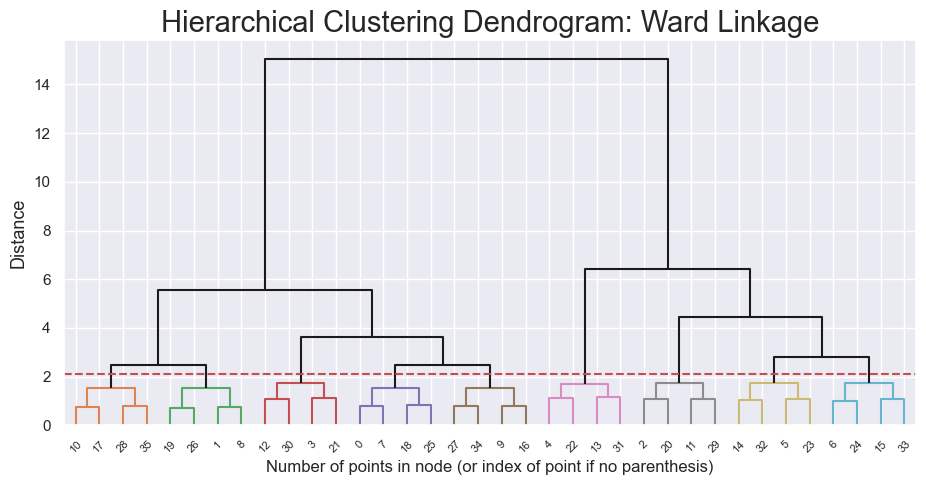

In [239]:
# Plot the corresponding dendrogram
sns.set()
fig = plt.figure(figsize=(11,5))
# The Dendrogram parameters need to be tuned
Y_THRESHOLD = 2.1
dendrogram(linkage_matrix, truncate_mode='level', p=5, color_threshold=Y_THRESHOLD, above_threshold_color='k')
    # You can play with 'truncate_mode' and 'p' define what level the dendrogram shows
    # above_threshold_color='k' forces black color for the lines above the threshold)
plt.hlines(Y_THRESHOLD, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram: Ward Linkage', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'Distance', fontsize=13)
plt.show()

In [240]:
# Performing HC
hclust = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=9)
hc_labels = hclust.fit_predict(df_centroids)
hc_labels

array([7, 3, 0, 2, 5, 6, 1, 7, 3, 4, 8, 0, 2, 5, 6, 1, 4, 8, 7, 3, 0, 2,
       5, 6, 1, 7, 3, 4, 8, 0, 2, 5, 6, 1, 4, 8])

In [241]:
df_centroids['merged_labels'] = hc_labels
df_centroids

Latitude  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name                          
High-Income East         Consistent low travelers\n(Use points)    -0.781096   
                         Formers Points accumulator\n(2020)        -0.783570   
                         Gained customers\n(Now traveling average) -0.777442   
                         Growing travelers\n(Now average)          -0.774812   
                         Lost custumers\n(Traveled more before)    -0.776537   
                         Low-travel individuals                    -0.772728   
                         No_transactions                           -0.777732   
                         Points accumulator currently\n(2021)      -0.790992   
                         Stable average travelers\n(Loyal)         -0.769701   
High-Income West         Consistent low travelers\n(Use points)    -0.149861   
                         Formers Points accumulator\n(2020)        -0.152568   
                         Gained customers\n(Now traveling average) -0.128484   
                         Growing travelers\n(Now average)          -0.142680   
                         Lost custumers\n(Traveled more before)    -0.201114   
                         Low-travel individuals                    -0.134761   
                         No_transactions                           -0.133901   
                         Points accumulator currently\n(2021)      -0.138543   
                         Stable average travelers\n(Loyal)         -0.119706   
Low-Income East          Consistent low travelers\n(Use points)    -0.775399   
                         Formers Points accumulator\n(2020)        -0.778343   
                         Gained customers\n(Now traveling average) -0.776279   
                         Growing travelers\n(Now average)          -0.763990   
                         Lost custumers\n(Traveled more before)    -0.779896   
                         Low-travel individuals                    -0.781234   
                         No_transactions                           -0.775834   
                         Points accumulator currently\n(2021)      -0.785233   
                         Stable average travelers\n(Loyal)         -0.774286   
Low-Income West          Consistent low travelers\n(Use points)    -0.108875   
                         Formers Points accumulator\n(2020)        -0.128313   
                         Gained customers\n(Now traveling average) -0.153754   
                         Growing travelers\n(Now average)          -0.146559   
                         Lost custumers\n(Traveled more before)    -0.150623   
                         Low-travel individuals                    -0.153097   
                         No_transactions                           -0.135311   
                         Points accumulator currently\n(2021)      -0.147549   
                         Stable average travelers\n(Loyal)         -0.136001   

                                                                    Longitude  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name                           
High-Income East         Consistent low travelers\n(Use points)      0.462893   
                         Formers Points accumulator\n(2020)          0.461423   
                         Gained customers\n(Now traveling average)   0.464587   
                         Growing travelers\n(Now average)            0.464527   
                         Lost custumers\n(Traveled more before)      0.445028   
                         Low-travel individuals                      0.467042   
                         No_transactions                             0.472676   
                         Points accumulator currently\n(2021)        0.450171   
                         Stable average travelers\n(Loyal)           0.472276   
High-Income West         Consistent low travelers\n(Use points)     -0.593445   
                         Formers Points accumulator\n(2

In [242]:
cluster_mapper = df_centroids['merged_labels'].to_dict()
cluster_mapper  


{('High-Income East', 'Consistent low travelers\n(Use points)'): 7,
 ('High-Income East', 'Formers Points accumulator\n(2020)'): 3,
 ('High-Income East', 'Gained customers\n(Now traveling average)'): 0,
 ('High-Income East', 'Growing travelers\n(Now average)'): 2,
 ('High-Income East', 'Lost custumers\n(Traveled more before)'): 5,
 ('High-Income East', 'Low-travel individuals'): 6,
 ('High-Income East', 'No_transactions'): 1,
 ('High-Income East', 'Points accumulator currently\n(2021)'): 7,
 ('High-Income East', 'Stable average travelers\n(Loyal)'): 3,
 ('High-Income West', 'Consistent low travelers\n(Use points)'): 4,
 ('High-Income West', 'Formers Points accumulator\n(2020)'): 8,
 ('High-Income West', 'Gained customers\n(Now traveling average)'): 0,
 ('High-Income West', 'Growing travelers\n(Now average)'): 2,
 ('High-Income West', 'Lost custumers\n(Traveled more before)'): 5,
 ('High-Income West', 'Low-travel individuals'): 6,
 ('High-Income West', 'No_transactions'): 1,
 ('High-Inc

In [243]:
inverse_cluster_mapper = {}

for key, value in cluster_mapper.items():
    # If the value isn't in the new dict yet, create a list
    if value not in inverse_cluster_mapper:
        inverse_cluster_mapper[value] = []
    
    # Append the original key to that list
    inverse_cluster_mapper[value].append(key)
inverse_cluster_mapper

{7: [('High-Income East', 'Consistent low travelers\n(Use points)'),
  ('High-Income East', 'Points accumulator currently\n(2021)'),
  ('Low-Income East', 'Consistent low travelers\n(Use points)'),
  ('Low-Income East', 'Points accumulator currently\n(2021)')],
 3: [('High-Income East', 'Formers Points accumulator\n(2020)'),
  ('High-Income East', 'Stable average travelers\n(Loyal)'),
  ('Low-Income East', 'Formers Points accumulator\n(2020)'),
  ('Low-Income East', 'Stable average travelers\n(Loyal)')],
 0: [('High-Income East', 'Gained customers\n(Now traveling average)'),
  ('High-Income West', 'Gained customers\n(Now traveling average)'),
  ('Low-Income East', 'Gained customers\n(Now traveling average)'),
  ('Low-Income West', 'Gained customers\n(Now traveling average)')],
 2: [('High-Income East', 'Growing travelers\n(Now average)'),
  ('High-Income West', 'Growing travelers\n(Now average)'),
  ('Low-Income East', 'Growing travelers\n(Now average)'),
  ('Low-Income West', 'Growing

In [245]:
df_multi_perspective['merged_labels'] = df_multi_perspective.apply(
    lambda row: cluster_mapper[(row['Demographic_Cluster_Name'], row['Behavioral_Year_Cluster_Name'])],
    axis=1
)
df_multi_perspective

,Province or State,City,Latitude,Longitude,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,...,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12,Demographic_Cluster,Demographic_Cluster_Name,Behavioral_Year_Cluster_Name,merged_labels
Loyalty#,,,,,,,,,,,,,,,,,,,,,
480934,Ontario,Toronto,43.653225,-79.383186,female,Bachelor,Urban,70146.0,Married,Star,...,49.7040,44.9366,44.5399,33.8046,-24.3761,-7.3610,3,High-Income East,Stable average travelers\n(Loyal),3
549612,Alberta,Edmonton,53.544388,-113.490930,male,College,Rural,0.0,Divorced,Star,...,-142.9017,76.7735,24.3200,33.6881,35.8801,27.1500,2,Low-Income West,Formers Points accumulator\n(2020),8
429460,British Columbia,Vancouver,49.282730,-123.120740,male,College,Urban,0.0,Single,Star,...,0.0000,16.8765,56.8163,0.0000,1.0278,45.7556,2,Low-Income West,Lost custumers\n(Traveled more before),5
608370,Ontario,Toronto,43.653225,-79.383186,male,College,Suburban,0.0,Single,Star,...,0.0000,0.0000,9.2783,53.1249,29.2410,-10.2270,0,Low-Income East,Formers Points accumulator\n(2020),3
530508,Quebec,Hull,45.428730,-75.713364,male,Bachelor,Suburban,97832.0,Married,Star,...,55.3928,73.4215,68.3248,0.0000,40.8525,2.1200,3,High-Income East,Points accumulator currently\n(2021),7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823768,British Columbia,Vancouver,49.282730,-123.120740,female,College,Rural,0.0,Married,Star,...,92.8240,62.3969,73.6945,10.2700,0.0000,92.2102,2,Low-Income West,Stable average travelers\n(Loyal),8
680886,Saskatchewan,Regina,50.445210,-104.618900,female,Bachelor,Rural,78310.0,Married,Star,...,96.8306,-47.4300,-26.0539,0.4300,3.0301,20.2400,1,High-Income West,Stable average travelers\n(Loyal),8
776187,British Columbia,Vancouver,49.282730,-123.120740,male,College,Urban,0.0,Single,Star,...,54.2446,76.9234,11.6135,-65.5510,29.2889,23.5600,2,Low-Income West,Stable average travelers\n(Loyal),8


In [246]:
print(df_multi_perspective['merged_labels'].value_counts().sort_index())

merged_labels
0    1448
1    1471
2     914
3    3130
4    2081
5     660
6    1473
7    3335
8    2060
Name: count, dtype: int64
